# 
Analysis of time spent in sync cluster (In Progress)

Done:  
1. Also include time spent in sync state for transitions which never fall back
2. Plot - Y axis: Number of trasitions; X axis: Timesteps/time
3. Defined algo in notebook
4. Completed and plotted for 200 iterations data
5. Plot for 1000 iteratin data


To do:
1. Define function in analysis.py.
2.  Do SEM

Conclusion:  

Time spent in sync state reduces when NOI are removed

#### Import libraries


In [26]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc


import statistics
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import glob

#### Create objects for classes


In [27]:
reader=DataRead()
analyse = AnalysisFunc()

# Function to calculate time spent in sync state considering transitions which does not fall back


In [30]:
def compute_time_spent(df,sim_time):
    """This takes input as the global order dataframe and computes time spent in sync state for evry iteration which has transition.

        Args:
            df (dataframe): global synchrony order (timesteps * number of iterations)
            sim_time (integer): Total time of simulation for an iteration in time units (eg. 40000 timestep with 0.02 timestep is 2000 time units)

        Returns:
            dictionary: Returns sync_dict with keys ['counts','time','time_spent']
    """
    # call compute param to know which iterations have single transitions and which fell back or had multiple transitions
    
    # to store the sync time for every iteration 
    sync_time=[]
    
    # call compute_param to get lists of iterations having transitions
    param=analyse.compute_param(df,0.05)
    
    # lst1 store iteration numbers which had transitions (single and multiple both)
    lst1=param['itr_tran']
    # lst2 stores iteration numbers which have fall back or multiple transitions 
    lst2=param['itr_st']
    
    # finding only those iterations which have only single transitions
    
    itr_list=set(lst1)-set(lst2)
    # print(f'itr_list is {itr_list}')
    
    # iterating over itr_list iterations to find out time spent in sync state
    for i in itr_list:
        df_smooth=analyse.smooth(df[i])
        pm=analyse.trans_state_time(df_smooth,0.05)
        st=sim_time-pm['low_cros'][0]
        sync_time.append(st)
    
    #print(sync_time)
    #print(len(sync_time))
    #print(len(itr_list))
    #print(param['sync'])
    
    # merging both time spent for single transition and multiple/fallback transition iterations
    time_spent=sync_time+param['sync']
    time_spent.sort()
    
    #print(time_spent)
    # print(len(time_spent))
    #print('The number of iterations with transitions',len(param['itr_tran']))


    # make time comparision list

    time = list(range(50,sim_time,50))
    # make list of zeros to increment accordingly
    
    counts = [0]*len(time)
    
    # comparing with time spent llist
    
    for sync in time_spent:
        for i, t in enumerate(time):
            ind = 0
            if sync < t:
                while ind<i:
                    counts[ind]+=1
                    ind+=1
                break
    
    #print(counts)

    keys=['counts','time','time_spent']
    values=[counts,time,time_spent]
    sync_dict = dict(zip(keys,values))
    return sync_dict
   
    



## Plot of NOI (having 200 iterations each)


Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]
Number of transitions / 100 iteration [1, 60, 118]
Number of transition [0, 3, 5, 7, 10, 11, 13, 15, 16, 17, 19, 20, 21, 22, 25, 26, 28, 30, 31, 35, 36, 38, 39, 41, 44, 46, 47, 49, 50, 52, 53, 54, 55, 60, 63, 66, 69, 71, 72, 74, 76, 77, 78, 79

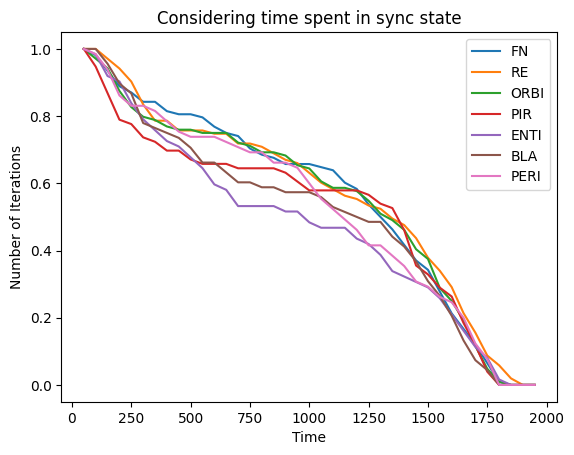

In [33]:
names = ['FN', 'RE', 'ORBI', 'PIR', 'ENTI', 'BLA', 'PERI']  # List of names to iterate through

for name in names:
    file_path = f'raw/{name}/itr_200.bz2'
    df_itr = reader.data_read_bz2(file_path)
    
    plot_data=compute_time_spent(df_itr,2000)
    time_arr=np.array(plot_data['time'])
    count_arr = np.array(plot_data['counts'])
    y=count_arr/count_arr[0]
    plt.plot(time_arr,y,label=name)
    
plt.title('Considering time spent in sync state')
plt.xlabel('Time')
plt.ylabel('Number of Iterations')
plt.legend()



## Plot of 1000 iteration data


In [ ]:
data_folder = Path(f'../../data/processed')
print(data_folder)
# Use glob to match files with a pattern
#f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_*.bz2"))
print(files)

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]
    
    df_itr = pd.read_pickle(f,compression='bz2')
    
    plot_data=compute_time_spent(df_itr,2000)
    time_arr=np.array(plot_data['time'])
    count_arr = np.array(plot_data['counts'])
    y=count_arr/count_arr[0]
    plt.plot(time_arr,y,label=name_suffix)
    #plt.plot(plot_data['time'],plot_data['counts'],label=name_suffix)
    
plt.title('Considering time spent in sync state')
plt.xlabel('Time')
plt.ylabel('Number of Iterations')
plt.legend()



../../data/processed
['../../data/processed/itr_bla.bz2', '../../data/processed/itr_fn.bz2', '../../data/processed/itr_pir.bz2', '../../data/processed/itr_re.bz2', '../../data/processed/itr_orbi.bz2', '../../data/processed/itr_enti.bz2', '../../data/processed/itr_peri.bz2']
Number of transitions / 100 iteration [0, 37, 76, 110, 146, 178, 211, 255, 287, 324, 359]
Number of transition [6, 7, 12, 22, 23, 26, 27, 29, 30, 35, 37, 43, 44, 47, 48, 54, 57, 59, 62, 63, 64, 66, 67, 69, 73, 78, 79, 85, 92, 93, 98, 104, 106, 109, 110, 112, 115, 117, 121, 125, 130, 134, 135, 141, 142, 145, 148, 149, 151, 156, 158, 159, 162, 166, 168, 172, 173, 177, 180, 181, 182, 184, 187, 191, 192, 193, 197, 198, 210, 211, 214, 218, 223, 224, 226, 227, 228, 229, 232, 237, 239, 245, 246, 247, 250, 258, 262, 264, 274, 281, 283, 295, 296, 297, 298, 303, 305, 314, 320, 322, 326, 328, 329, 333, 334, 336, 342, 343, 345, 347, 348, 350, 351, 356, 359, 360, 365, 368, 370, 371, 375, 378, 382, 384, 385, 392, 395, 396, 397, 3

## Plot with error bars using SEM as error bar length


#### Steps for bootstrapping

1. Take a random set of 200 iterations for 500 times
2. You will get 500 sets of data points
3. For each data point, 

In [5]:
df=reader.data_read_bz2('processed/itr_re.bz2')



In [6]:
df.shape

(40000, 1000)

In [14]:
bs_values = [] # list to store values
for i in range(0,500):
    df_rand=df.sample(n=200,axis='columns') 
    df_rand.columns=list(range(0,200))
    plot_data=compute_time_spent(df_rand,2000)
    time_arr=np.array(plot_data['time'])
    count_arr = np.array(plot_data['counts'])
    y=count_arr/count_arr[0]
    bs_values.append(y)


    
    




# check = analyse.compute_param(df_rand,0.05)
# check['']


#plot_data=compute_time_spent(df_rand,2000)



Number of transitions / 100 iteration [2, 52, 106]
Number of transition [0, 1, 3, 4, 5, 6, 12, 16, 19, 22, 23, 28, 30, 31, 32, 33, 36, 40, 41, 46, 48, 49, 50, 57, 59, 62, 63, 69, 70, 72, 75, 78, 80, 81, 82, 83, 85, 89, 90, 94, 97, 98, 99, 101, 105, 106, 107, 111, 112, 113, 114, 119, 122, 123, 125, 126, 127, 128, 130, 133, 134, 135, 141, 145, 146, 147, 149, 151, 153, 155, 156, 160, 164, 169, 170, 172, 179, 183, 187, 188, 189, 192, 196, 198]
Number of transition with more than one transition or a fall back [0, 3, 6, 19, 23, 40, 46, 50, 70, 75, 81, 90, 97, 106, 112, 114, 119, 122, 130, 160, 164, 169, 172, 187, 188]
59
[80.45, 97.35000000000001, 99.325, 108.2, 140.69999999999982, 147.35000000000002, 156.35000000000002, 157.20000000000002, 160.15, 162.19999999999982, 164.39999999999986, 169.4, 178.0, 200.10000000000002, 220.85000000000002, 224.3, 226.20000000000002, 228.32, 286.5, 340.95000000000005, 341.20000000000005, 372.95000000000005, 434.95000000000005, 438.90000000000003, 446.3499999

In [15]:
len(bs_values)



500

In [ ]:
bs_val_df=pd.DataFrame(bs_values).T
bs_val_df.head()
pd.to_pickle(bs_val_df,'../../data/raw/sem_data.bz2',compression='bz2')
df=reader.data_read_bz2('raw/sem_data.bz2')

df.head()

#### Taking average  for each row


In [11]:
df=reader.data_read_bz2('raw/sem_data.bz2')


df.head()


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.964286,0.957895,0.987654,0.989691,0.965909,0.981481,0.980583,0.981308,0.971429,0.937500,...,0.952381,0.989899,0.989691,0.959184,0.971698,0.960396,0.954023,0.971963,0.978495,0.980583
2,0.928571,0.873684,0.839506,0.917526,0.943182,0.898148,0.941748,0.887850,0.923810,0.857143,...,0.923810,0.959596,0.938144,0.877551,0.933962,0.891089,0.908046,0.887850,0.870968,0.893204
3,0.845238,0.842105,0.765432,0.886598,0.909091,0.833333,0.883495,0.869159,0.895238,0.794643,...,0.876190,0.909091,0.835052,0.806122,0.849057,0.871287,0.862069,0.841121,0.817204,0.873786
4,0.785714,0.736842,0.728395,0.804124,0.784091,0.777778,0.834951,0.813084,0.866667,0.723214,...,0.819048,0.888889,0.793814,0.755102,0.764151,0.792079,0.827586,0.766355,0.741935,0.796117


### Plot error bars with SEM


In [21]:
mean = df.mean(axis=1)
sem= df.sem(axis=1)






In [22]:
df=reader.data_read_bz2('raw/RE/itr_200.bz2')
l=compute_time_spent(df,2000)


t=l['time']





Number of transitions / 100 iteration [1, 60, 118]
Number of transition [0, 3, 5, 7, 10, 11, 13, 15, 16, 17, 19, 20, 21, 22, 25, 26, 28, 30, 31, 35, 36, 38, 39, 41, 44, 46, 47, 49, 50, 52, 53, 54, 55, 60, 63, 66, 69, 71, 72, 74, 76, 77, 78, 79, 81, 87, 88, 89, 90, 92, 93, 94, 97, 101, 103, 107, 108, 109, 110, 113, 114, 115, 116, 119, 121, 124, 125, 129, 130, 131, 136, 137, 138, 140, 143, 146, 147, 148, 149, 150, 151, 152, 153, 155, 156, 159, 164, 165, 167, 169, 171, 172, 173, 174, 176, 178, 182, 184, 185, 189, 190, 196, 199]
Number of transition with more than one transition or a fall back [0, 5, 7, 10, 11, 19, 35, 39, 74, 78, 79, 81, 108, 116, 125, 130, 143, 147, 149, 152, 155, 169, 178, 182, 199]
78
[105.05000000000001, 111.7, 135.65, 159.25, 172.0999999999999, 185.3, 209.9333333333333, 217.75, 218.45000000000002, 226.9, 253.8, 260.05, 266.675, 268.7, 270.2833333333333, 284.7, 288.65000000000003, 303.0, 309.40000000000003, 317.8, 326.75, 334.70000000000005, 404.54999999999995, 413.15

Text(0.5, 1.0, 'Plot of RE with error bars ')

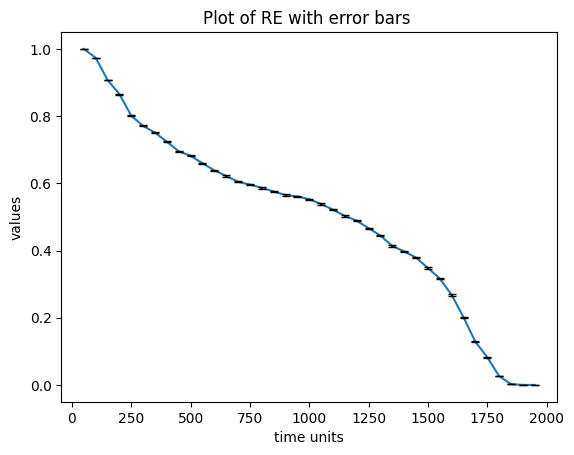

In [25]:
fig,ax = plt.subplots()
ax.plot(t,mean)
ax.errorbar(t,mean,yerr=sem,fmt='none',ecolor='k',capsize=3)

plt.xlabel('time units')
plt.ylabel('values')
plt.title('Plot of RE with error bars ')






In [15]:
sem.shape


(40000,)

In [19]:
df_mean.sem()

0.04306440699500741

In [22]:
len(t)



39

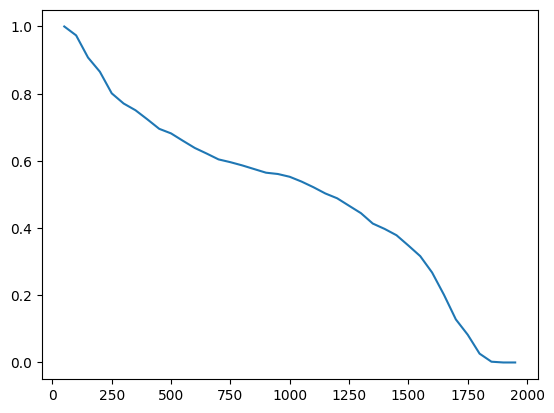

In [24]:
plt.plot(t,df_mean)



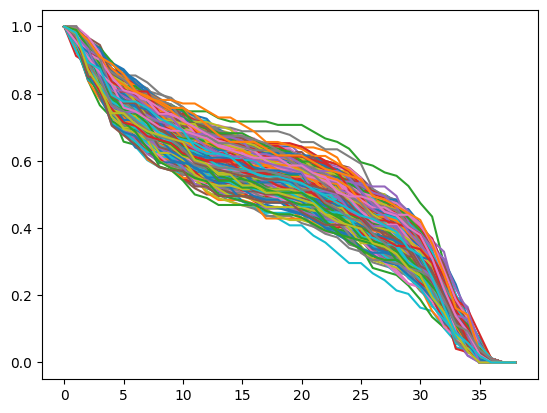

In [16]:
plt.plot(df)

plt.show()
